# Bjerknes feedback changes over time

## imports

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import copy
import time

# Import custom modules
import src.utils

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## Specify kwargs

In [20]:
# Specify T variable
T_VAR = "T_50"

## should we subtract median?
SUBTRACT_MEDIAN = True

## specify MLD
MLD = 50

## MONTH FOR PLOTTING
SEL_MONTH = lambda x: x.sel(month=slice(1, 3)).mean("month")
MONTH0 = 1

## WHETHER TO COMPUTE BY MEMBER
BY_MEMBER = True

if BY_MEMBER:
    DIMS = ["time"]
else:
    DIMS = ["time", "member"]

## Funcs

### Misc

In [21]:
def window(x, subtract_median=SUBTRACT_MEDIAN):
    """get data in windows"""
    x_windowed = src.utils.get_windowed(x, stride=120)

    ## handle median case
    if subtract_median:
        median = x_windowed.groupby("time.month").median(["time", "member"])
        x_windowed = x_windowed.groupby("time.month") - median

    return x_windowed


def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom


def regress_over_time(
    data_windowed,
    x_vars,
    y_vars,
    dims=["time", "member"],
):
    """regression over time"""

    ## shared args
    kwargs = dict(x_vars=x_vars, y_vars=y_vars, dims=dims)

    ## do regression
    coefs = data_windowed.groupby("time.month").map(src.utils.regress_xr_proj, **kwargs)

    return coefs


def regress_wrapper(data, x_vars, y_var, y_fn, dims=["time", "member"]):
    """regression over time"""

    ## prep data
    y_data = src.utils.reconstruct_wrapper(data[[f"{y_var}", f"{y_var}_comp"]], fn=y_fn)

    ## subset for data
    data_ = xr.merge([data[x_vars], y_data])

    return regress_over_time(data_, x_vars=x_vars, y_vars=[y_var], dims=dims)


def frac_change(x):
    """fractional change"""
    return x / x.isel(year=0) - 1


def check_dims(x):
    """make sure dimensions are ok before averaging"""
    ## check if latitude is in ssh
    if "latitude" in x.dims:
        x_ = copy.deepcopy(x)
    else:
        x_ = x.expand_dims("latitude")

    ## check if z_t is in ssh
    if "z_t" in x.dims:
        x_ = copy.deepcopy(x_)
    else:
        x_ = x_.expand_dims("z_t")

    return x_


def get_ddt(data):
    """differentiate with respect to time"""
    data_ = copy.deepcopy(data)
    data_ = data_.assign_coords({"t_idx": ("time", np.arange(len(data_.time)))})
    data_ = data_.swap_dims({"time": "t_idx"})
    return data_.differentiate("t_idx").swap_dims({"t_idx": "time"})


def save(fig, fname, do_save=False, **kwargs):
    """save figure to results."""

    ## set save filepath
    save_dir = SAVE_FP / "figs"

    if do_save:

        ## save figure
        fig.savefig(
            save_dir / f"{fname}_{FIG_SUFFIX}.pdf", format="pdf", dpi=500, **kwargs
        )

        ## close figure
        plt.close(fig)

    return

### Plotting

In [22]:
def make_scatter_ax(
    ax, anom_, xvar, yvar, month, label, verbose=True, by_season=True, **kwargs
):
    """scatter plot of data for given month"""

    ## prep func
    if by_season:
        get_season = lambda x: src.utils.sel_month(
            x.resample({"time": "QS-JAN"}).mean(), month
        )

    else:
        get_season = lambda x: src.utils.sel_month(x, month)

    prep = lambda x: get_season(x).transpose("time", "member")

    ## get plot data
    plot_data = (prep(anom_[xvar]), prep(anom_[yvar]))

    ## get stats
    corr = xr.corr(*plot_data)
    cov = xr.cov(*plot_data)
    m = cov / plot_data[0].var()

    ## get label
    if verbose:
        legend = f"m = {m.item():.1e}\nr = {corr.item():.2f}"
    else:
        legend = None

    ## plot data
    ax.scatter(*plot_data, s=3, label=legend, **kwargs)
    ax.set_title(f"{label}")

    ## formatting
    ax_kwargs = dict(ls="--", c="gray", lw=0.5)
    ax.axvline(0, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)

    if verbose:
        ax.legend(prop=dict(size=10))

    return ax


def make_scatter(anom_, xvar, yvar, month, by_season=True, verbose=True, **kwargs):
    """scatter plot of data for given month"""

    fig, axs = plt.subplots(1, 4, figsize=(11, 2.5), layout="constrained")

    if "year" in anom_:
        for ax, year in zip(
            axs,
            [1870, 2010, 2050, 2080],
        ):

            ## scatter plot of data
            ax = make_scatter_ax(
                ax,
                anom_.sel(year=year, method="nearest"),
                xvar=xvar,
                yvar=yvar,
                month=month,
                by_season=by_season,
                label=year,
                verbose=verbose,
                **kwargs,
            )

    else:

        for ax, t_idx, label in zip(
            axs,
            [["1850", "1879"], ["1995", "2024"], ["2035", "2064"], ["2071", "2100"]],
            ["1865", "2010", "2050", "2085"],
        ):

            ## helper func
            prep = lambda x: x.sel(time=slice(*t_idx))

            ## scatter plot of data
            ax = make_scatter_ax(
                ax,
                prep(anom_),
                xvar=xvar,
                yvar=yvar,
                month=month,
                by_season=by_season,
                label=label,
            )

    ## format/scale axes
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs


def plot_timeseries(coefs, sel_fn=lambda x: x):
    """plot timeseries comparison"""

    fig, axs = plt.subplots(1, 3, figsize=(8, 2.5))

    ## loop thru pos and negative
    for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

            ## plot neutral and pos/or neg
            for name_, color_ in zip(["all", name], ["k", color]):

                ## finally, plot data
                axs[i].plot(
                    coefs.year,
                    sel_fn(coefs)[name_].quantile(q=q, dim="member"),
                    c=color_,
                    lw=lw,
                )

            ## plot on shared axs
            axs[2].plot(
                coefs.year,
                sel_fn(coefs)[name].quantile(q=q, dim="member"),
                c=color,
                lw=lw,
            )

    ## formatting
    for ax in axs:
        ax.set_xticks([1870, 2010, 2080])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axvline(2010, **ax_kwargs)
        ax.axhline(0, **ax_kwargs)
    src.utils.set_lims(axs)

    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs


def plot_zonal_structure(coefs, sel_fn=lambda x: x):
    """plot zonal structure of coefficients over time"""

    fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

    for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

        ## get data for year
        ax.set_title(y)
        coefs_y = sel_fn(coefs).sel(year=y, method="nearest")

        ## select data
        for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

            ax.plot(coefs.longitude, coefs_y[n].mean("member"), c=color)

    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    for ax in axs:
        ax.set_xticks([140, 190, 240, 280])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axhline(0, **ax_kwargs)

    return fig, axs


def add_vticks(axs, xticks, xlines=None):
    """add vertical lines to axs"""

    ## specify line style
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)

    ## loop thru axs
    for ax in axs:
        ax.set_xticks(xticks)
        if xlines is not None:
            for x0 in xlines:
                ax.axvline(x0, **ax_kwargs)

    return


def plot_vertical_structure(coefs, sel_fn):
    """plot vertical structure of coefficients over time"""

    fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

    for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

        ## get data for year
        ax.set_title(y)
        coefs_y = sel_fn(coefs).sel(year=y, method="nearest")

        ## select data
        for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

            ax.plot(coefs_y[n].mean("member"), coefs.z_t, c=color)

    for ax in axs:
        ax.set_ylim([150, 5])

        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axhline(50, **ax_kwargs)
        ax.axhline(80, **ax_kwargs)
        ax.axvline(0, **ax_kwargs)

    src.utils.set_lims(axs)
    axs[0].set_yticks([0, 50, 80])
    for ax in axs[1:]:
        ax.set_yticks([])
    return fig, axs

## Load data

#### $T$, $h$

In [23]:
## open data
# Th = src.utils.load_cesm_indices(load_z20=True)
Th_total = src.utils.load_cesm_indices_3d(mld=MLD)

## compute anoms
Th = Th_total - Th_total.mean("member")

### Spatial data

#### most data

In [24]:
## load spatial data
forced, anom = src.utils.load_consolidated()

## compute anoms
Th_3d = src.utils.load_cesm_3d().interp({"longitude": anom.longitude})
Th_3d_forced = Th_3d.mean("member")
Th_3d_anom = Th_3d - Th_3d_forced

## add T,h information
anom = xr.merge([anom, Th, Th_3d_anom])

anom["ddt_T_50"] = get_ddt(anom["T_50"])
anom["ddt_T_80"] = get_ddt(anom["T_80"])

## Analysis

### T vs. ddt(SST)$

In [25]:
## specify which variable to use ("T" or "sst")
Y_VAR = f"ddt_T_{MLD}"
X_VAR = f"T_{MLD}"

## get data for regression (OHC)
vlon = dict(longitude=Th_3d.longitude)
R_data = window(xr.merge([anom[[X_VAR, "h"]], anom[Y_VAR].sel(vlon)]))
regress_kwargs = dict(x_vars=[X_VAR, "h"], y_vars=[Y_VAR], dims=DIMS)
regress_helper = lambda x: regress_over_time(x, **regress_kwargs)[Y_VAR]

## do the regression
print("regress all")
R_all = regress_helper(R_data)
print("regress pos")
R_pos = regress_helper(R_data.where(R_data[X_VAR] > 0))
print("regress neg")
R_neg = regress_helper(R_data.where(R_data[X_VAR] < 0))

## merge into single dataarray
R_struct = xr.merge([R_all.rename("all"), R_pos.rename("pos"), R_neg.rename("neg")])

## convert to 1/yr
R_struct = 12 * R_struct

regress all
regress pos
regress neg


#### Plot spatial structure

reconstruct spatial strucure

In [26]:
def reduce_x(x):

    ## get averaging dims
    idx = dict(longitude=slice(210, 270))
    # idx = dict(longitude=slice(190,240))

    return x.sel(idx).mean("longitude")

Plot


T_50


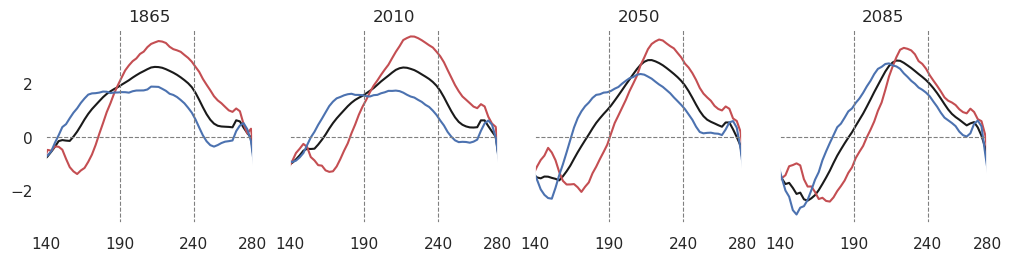


h


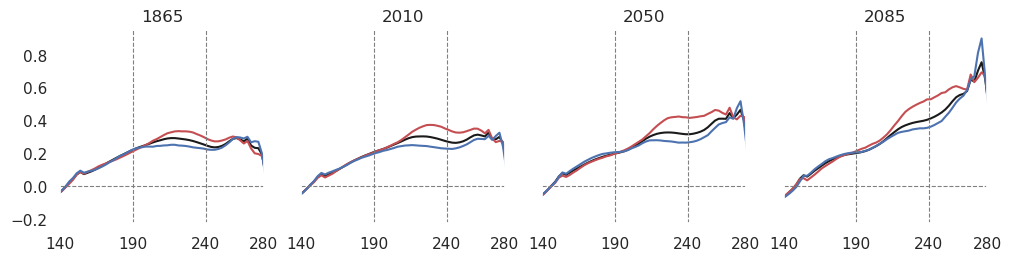

In [27]:
# SEL_MONTH = lambda x : x.sel(month=[10,11,12]).mean("month")
SEL_MONTH = lambda x: x.sel(month=[4, 5, 6]).mean("month")
# SEL_MONTH = lambda x : x.sel(month=[7,8,9]).mean("month")
for j in R_struct.j.values:
    print(f"\n{j}")
    fig, axs = plot_zonal_structure(R_struct.sel(j=j), sel_fn=SEL_MONTH)
    for ax in axs:
        ax.set_xlim([140, 280])

    add_vticks(axs, xticks=[140, 190, 240, 280], xlines=[190, 240])
    plt.show()

#### Timeseries


T_50


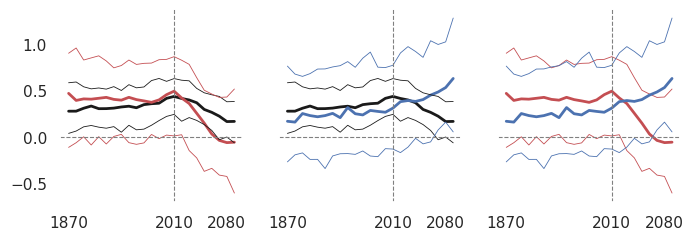


h


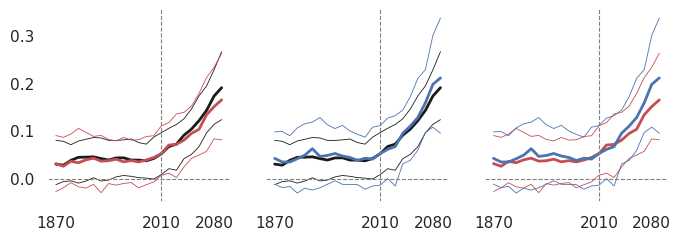

In [28]:
SEL_MONTH = lambda x: x.sel(month=slice(10, 12)).mean("month")

## get index
R = reduce_x(R_struct)

for j in R.j.values:
    print(f"\n{j}")
    fig, axs = plot_timeseries(coefs=R.sel(j=j), sel_fn=SEL_MONTH)
    plt.show()

#### Scatter plot

In [29]:
T_VAR

'T_50'


T_50


KeyError: "No variable named 'T_50'. Variables on the dataset include ['member', 'time', 't_idx', 'ddt_T_80', 'T_3', 'T_34', 'h_w', 'h']"

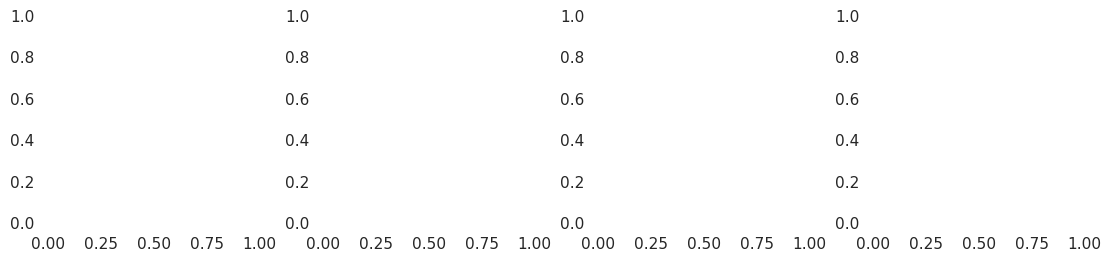

In [18]:
## specify y-variable
Y_VAR_sc = "T_80"

scatter_data = xr.merge(
    [
        reduce_x(anom[f"ddt_{Y_VAR_sc}"]),
        anom[[T_VAR, "T_3", "T_34", "h_w", "h"]],
    ]
)

for xvar in [X_VAR, "h_w", "h"]:
    print(f"\n{xvar}")
    fig, axs = make_scatter(
        scatter_data, xvar=xvar, yvar=f"ddt_{Y_VAR_sc}", month=6, by_season=False
    )
    plt.show()

In [ ]:
data_ = scatter_data.resample({"time": "QS-JAN"}).mean()
data_ = data_.isel(time=slice(1, None, 4))
# data_ = scatter_data.isel(time=slice(6,None,12))
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
for ax, t_idx in zip(axs, [("1850", "1880"), ("1995", "2025")]):
    ax.scatter(
        data_["h"].sel(time=slice(*t_idx)),
        data_["ddt_T_80"].sel(time=slice(*t_idx)),
        # data_["h"],
        # data_["T_3"],
        s=5,
    )

src.utils.set_lims(axs)
plt.show()

### Sverdrup balance

In [13]:
## specify which variable to use ("T" or "sst")
Y_VAR = f"thc"
X_VAR = f"T_3"

## get data for regression (OHC)
vlon = dict(longitude=Th_3d.longitude)
R_data = window(xr.merge([anom[X_VAR], anom[Y_VAR].sel(vlon)]))
regress_kwargs = dict(x_vars=[X_VAR], y_vars=[Y_VAR], dims=DIMS)
regress_helper = lambda x: regress_over_time(x, **regress_kwargs)[Y_VAR]

## do the regression
print("regress all")
R_all = regress_helper(R_data)
print("regress pos")
R_pos = regress_helper(R_data.where(R_data[X_VAR] > 0))
print("regress neg")
R_neg = regress_helper(R_data.where(R_data[X_VAR] < 0))

## merge into single dataarray
R_struct = xr.merge([R_all.rename("all"), R_pos.rename("pos"), R_neg.rename("neg")])

regress all
regress pos
regress neg


#### Plot spatial structure

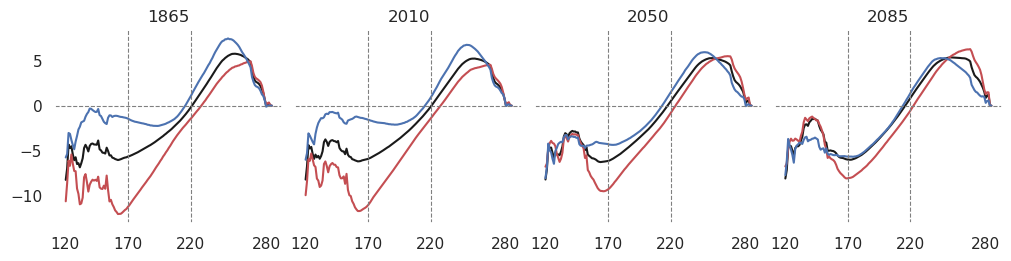

In [14]:
# SEL_MONTH = lambda x : x.sel(month=slice(10,12)).mean("month")
SEL_MONTH = lambda x: x.sel(month=slice(7, 12)).mean("month")
fig, axs = plot_zonal_structure(coefs=R_struct, sel_fn=SEL_MONTH)

add_vticks(axs, xticks=[120, 170, 220, 280], xlines=[170, 220])

plt.show()

#### Scatter

##### Compute inices

In [26]:
def get_he(x):
    """average over eastern Pacific"""

    ## lats/lons for averaging
    # idx = dict(longitude=slice(190, 240))
    idx = dict(longitude=slice(220, 270))

    return x.sel(idx).sum("longitude")


def get_hw(x):
    """average over western Pacific"""

    ## lats/lons for averaging
    idx = dict(longitude=slice(140, 200))

    return x.sel(idx).sum("longitude")

    return


def get_dh(x):
    """east-west difference"""

    return get_he(x) - get_hw(x)


# def reduce_x(x):

#     ## get averaging dims
#     e_idx = dict(longitude=slice(220,280))
#     w_idx = dict(longitude=slice(120,180))
#     # idx = dict(longitude=slice(190,240))

#     return x.sel(e_idx).mean("longitude") - x.sel(w_idx).mean("longitude")

In [27]:
# add to dataarray
for n, fn in zip(["he", "hw", "dh"], [get_he, get_hw, get_dh]):
    R_data[n] = fn(R_data["thc"])

##### Make plot

dh


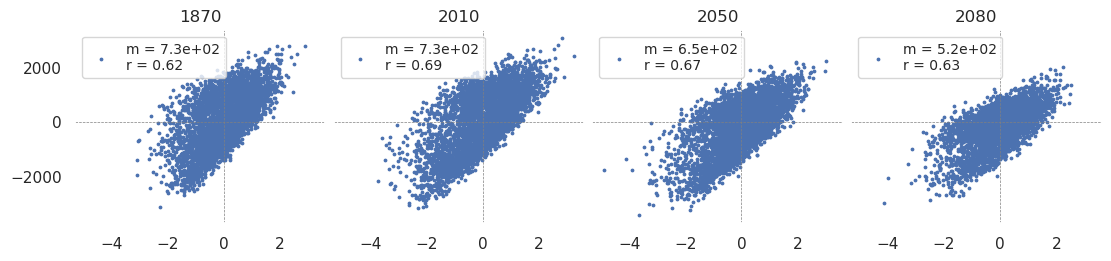

he


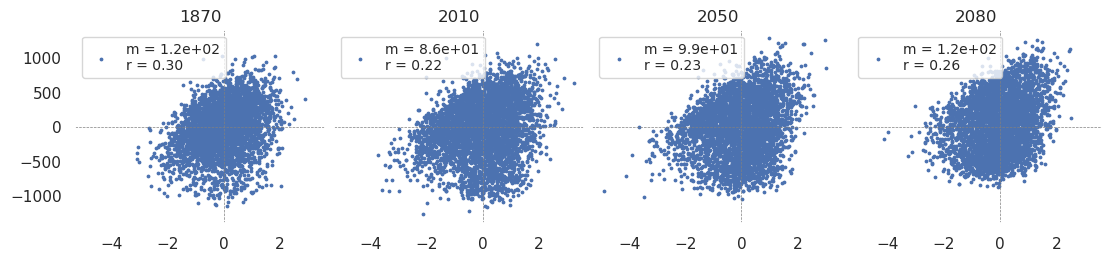

hw


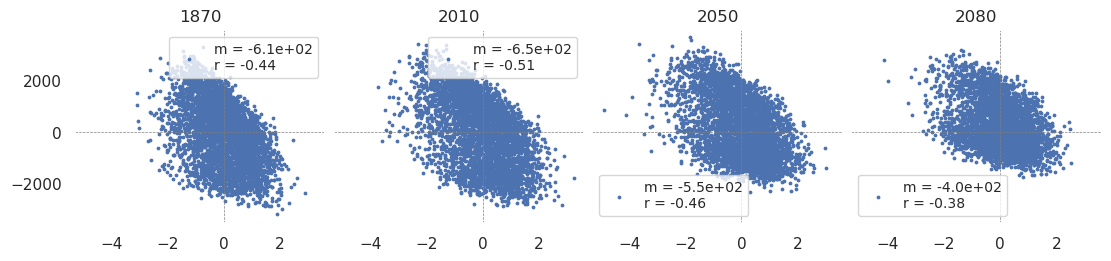

In [28]:
## specify kwargs
kwargs = dict(anom_=R_data, xvar=X_VAR, month=4, by_season=True)

for yvar in ["dh", "he", "hw"]:
    print(yvar)

    fig, axs = make_scatter(yvar=yvar, **kwargs)
    plt.show()

#### Timeseries

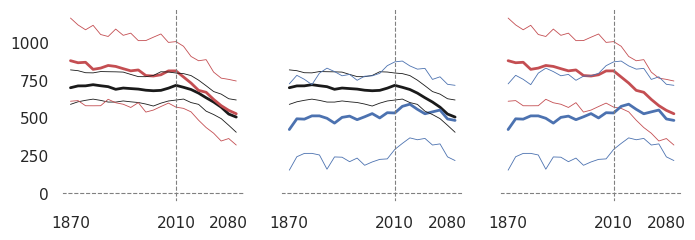

In [29]:
## compute beta index
beta_he = get_he(R_struct)
beta = get_dh(R_struct)

fig, axs = plot_timeseries(coefs=beta, sel_fn=SEL_MONTH)
plt.show()

### Thermal expansion

#### Compute

In [19]:
## get data for regression
ah_data = xr.merge([window(anom[["T_3", f"T_{MLD}"]].sel(vlon)), R_data["he"]])

In [20]:
regress_kwargs = dict(x_vars=["he"], y_vars=[f"T_{MLD}"], dims=DIMS)
regress_helper = lambda x: regress_over_time(x, **regress_kwargs)[f"T_{MLD}"]

## do the regression
print("regress all")
ah_all = regress_helper(ah_data)
print("regress pos")
ah_pos = regress_helper(ah_data.where(ah_data["he"] > 0))
print("regress neg")
ah_neg = regress_helper(ah_data.where(ah_data["he"] < 0))

## merge into single dataarray
ah_struct = xr.merge([ah_all.rename("all"), ah_pos.rename("pos"), ah_neg.rename("neg")])

regress all
regress pos
regress neg


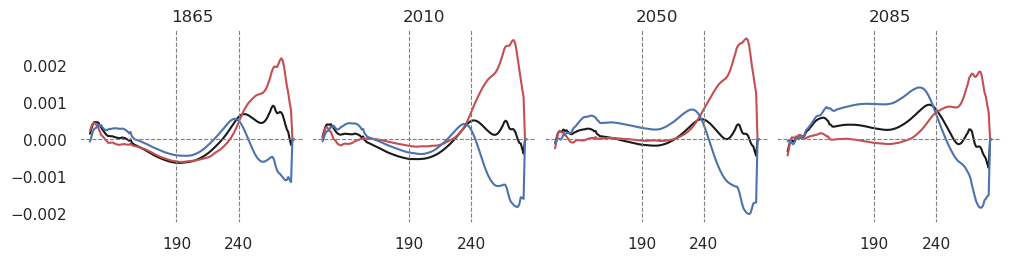

In [22]:
SEL_MONTH = lambda x: x.sel(month=slice(4, 6)).mean("month")
fig, axs = plot_zonal_structure(coefs=ah_struct, sel_fn=SEL_MONTH)

add_vticks(axs, xticks=[190, 240], xlines=[190, 240])

plt.show()

#### Scatter

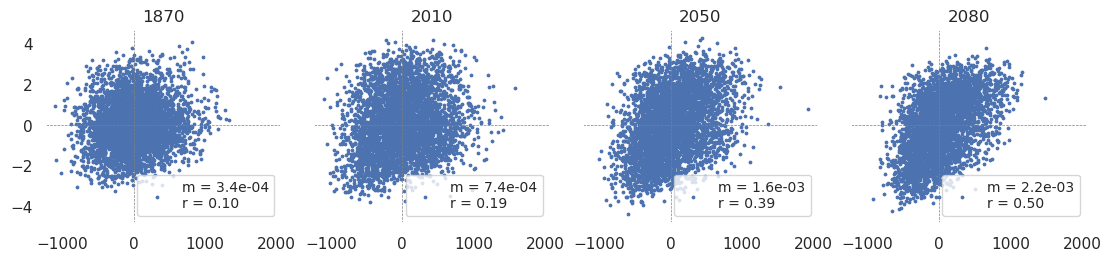

In [32]:
## specify kwargs
kwargs = dict(anom_=ah_data, xvar="he", yvar="T_3", month=1, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Time series

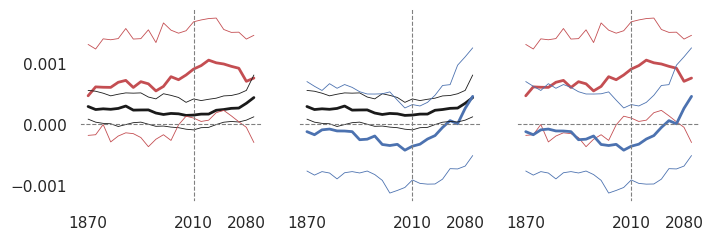

In [25]:
## get index
ah = ah_struct.sel(longitude=slice(210, 270)).mean("longitude")

fig, axs = plot_timeseries(coefs=ah, sel_fn=SEL_MONTH)
plt.show()

### zonal velocity

#### Load coefficients

In [ ]:
## load coefs
betau_proj = xr.merge(c["u"].rename(n) for n, c in coefs.items())

#### Plot structure

In [ ]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    return REDUCE_X(x)


def reduce_z(x):
    """Average over ML don't average over longitude yet"""

    return x.sel(z_t=slice(None, MLD)).mean("z_t")


def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("u"), anom["u_comp"]]),
        fn=reduce_z,
    )
    ## drop extra variables
    mu = coefs_["u"].squeeze(drop=True)

    return mu


def recon_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["u"], anom[f"u_comp"]]),
        fn=lambda y: reduce_x(reduce_z(y)),
    )

    return coefs_struct["u"]

In [ ]:
## load coefs
betau_struct = xr.merge(
    [recon_struct(betau_proj[v]).rename(v) for v in ["all", "pos", "neg"]]
)

# ## Get zonal T profile
T_bar = src.utils.reconstruct_wrapper(
    # xr.merge([clim["T"], forced["T_comp"]]),
    xr.merge([clim_norect["T"], forced["T_comp"]]),
    fn=lambda x: reduce_z(x),
)["T"]

## compute zonal advective feedback
## mult. by 12 to convert from K/mo to K/yr
zaf_struct = 12 * -src.utils.get_udTdx(u=betau_struct, T=T_bar)

In [ ]:
for v in [T_VAR, "h_w"]:
    print(v)

    fig, axs = plot_zonal_structure(coefs=zaf_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

#### Plot timeseries

In [ ]:
## compute gamma
zaf = reduce_x(zaf_struct)

fig, axs = plot_timeseries(coefs=zaf.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

#### Scatter

In [ ]:
scatter_data = xr.merge(
    [
        recon_idx(anom[["u"]]),
        anom[["T_3", "T_34", "h_w"]],
    ]
)

for xvar in [T_VAR, "h_w"]:
    fig, axs = make_scatter(scatter_data, xvar=xvar, yvar="u", month=MONTH0)
    plt.show()

### Surface temp

#### Load coefficients

In [ ]:
## load coefs
betaT_proj = xr.merge(c["T"].rename(n) for n, c in coefs.items())

#### Plot structure

In [ ]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    return REDUCE_X(x)


def reduce_x_discrete(x):
    """Get Tsub, but don't average over depth yet"""

    if T_VAR == "T_3":
        lon_range = [210, 270]
    else:
        lon_range = [190, 240]

    return x.sel(longitude=lon_range[1], method="nearest") - x.sel(
        longitude=lon_range[0], method="nearest"
    )


def reduce_z(x):
    """Average over ML don't average over longitude yet"""

    return x.sel(z_t=slice(None, MLD)).mean("z_t")


def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("T"), anom["T_comp"]]),
        fn=reduce_z,
    )
    ## drop extra variables
    mu = coefs_["T"].squeeze(drop=True)

    return mu


def recon_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["T"], anom[f"T_comp"]]),
        fn=lambda y: reduce_x_discrete(reduce_z(y)),
    )

    return coefs_struct["T"]

In [ ]:
## load coefs
betaT_struct = xr.merge(
    [recon_struct(betaT_proj[v]).rename(v) for v in ["all", "pos", "neg"]]
)

## Get u_bar
u_bar = src.utils.reconstruct_wrapper(
    # xr.merge([clim["u"], forced["u_comp"]]),
    xr.merge([clim_norect["u"], forced["u_comp"]]),
    fn=lambda x: reduce_z(x),
)["u"]

## compute dynamical damping
# multiply by 12 to convert from K/mo to K/yr
dd_struct = 12 * -src.utils.get_udTdx(u=u_bar, T=betaT_struct)

In [ ]:
for v in [T_VAR, "h_w"]:
    print(v)

    fig, axs = plot_zonal_structure(coefs=dd_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

#### Plot timeseries

In [ ]:
## compute gamma
dd = reduce_x(dd_struct)

fig, axs = plot_timeseries(coefs=dd.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

#### Scatter

In [ ]:
scatter_data = xr.merge(
    [
        recon_idx(anom[["T"]]),
        anom[["T_3", "T_34", "h_w"]],
    ]
)

for xvar in [T_VAR, "h_w"]:
    fig, axs = make_scatter(scatter_data, xvar=xvar, yvar="T", month=MONTH0)
    plt.show()

### NDH_x

In [ ]:
ndh_struct = 12 * -src.utils.get_udTdx(T=betaT_struct, u=betau_struct)

In [ ]:
for v in [T_VAR, "h_w"]:
    print(v)

    fig, axs = plot_zonal_structure(coefs=ndh_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

In [ ]:
## compute gamma
ndh = reduce_x(ndh_struct)

fig, axs = plot_timeseries(coefs=ndh.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

### sum of zonal

In [ ]:
zonal_struct = zaf_struct + dd_struct + ndh_struct
for v in [T_VAR, "h_w"]:
    print(v)

    fig, axs = plot_zonal_structure(coefs=zonal_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

In [ ]:
fig, axs = plot_timeseries(coefs=(zaf + dd + ndh).sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

### upwelling

#### Load coefficients

In [ ]:
## load coefs
betaw_proj = xr.merge(c["w"].rename(n) for n, c in coefs.items())

#### Plot structure

In [ ]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    # return REDUCE_X(x)
    return x.sel(longitude=slice(240, 280)).mean("longitude")


def reduce_z(x):
    """average over entrainment zone"""

    return x.sel(z_t=ENT_DEPTH_RANGE).mean("z_t")


def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("w"), anom["w_comp"]]),
        fn=reduce_z,
    )
    ## drop extra variables
    mu = coefs_["w"].squeeze(drop=True)

    return mu


def recon_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["w"], anom[f"w_comp"]]),
        fn=lambda y: reduce_x(reduce_z(y)),
    )

    return coefs_struct["w"]


def get_dT(x):
    """Get diff b/n Tsub and Tsurf, but don't average over longitude yet"""

    Tsurf = x.sel(z_t=slice(None, MLD)).mean("z_t")
    Tsub = x.sel(z_t=ENT_DEPTH_RANGE).mean("z_t")

    return Tsub - Tsurf

In [ ]:
## load coefs
betaw_struct = xr.merge(
    [recon_struct(betaw_proj[v]).rename(v) for v in ["all", "pos", "neg"]]
)

## get dTbar
dT_bar_struct = src.utils.reconstruct_wrapper(
    xr.merge([clim["T"], forced["T_comp"]]),
    fn=get_dT,
)["T"]

## compute ekman
# first, scale upwelling by mixed layer depth (50 m) and convert from m/mo to m/yr
w_H = 12 * betaw_struct / MLD
ekf_struct = dT_bar_struct * w_H

In [ ]:
## plot upwelling structure
print("w")
fig, axs = plot_zonal_structure(coefs=betaw_struct.isel(j=0), sel_fn=SEL_MONTH)
add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
for ax in axs:
    ax.set_xlim([210, 285])
add_vticks(axs, xticks=[240, 270], xlines=[240, 270])
# axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

plt.show()


## plot ekman structure
for v in [T_VAR, "h_w"]:
    print(f"ekf ({v})")

    fig, axs = plot_zonal_structure(coefs=ekf_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[240, 270], xlines=[240, 270])
    for ax in axs:
        ax.set_xlim([210, 285])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

#### Plot timeseries

In [ ]:
## compute EKF
ekf = reduce_x(ekf_struct)

fig, axs = plot_timeseries(coefs=ekf.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

## compute gamma
dT_bar = reduce_x(dT_bar_struct)

fig, axs = plot_timeseries(
    coefs=xr.ones_like(ekf.sel(j=T_VAR)) * dT_bar, sel_fn=SEL_MONTH
)
plt.show()

#### Scatter

In [ ]:
scatter_data = xr.merge(
    [
        recon_idx(anom[["w"]]),
        anom[["T_3", "T_34", "h_w"]],
    ]
)

for xvar in [T_VAR, "h_w"]:
    fig, axs = make_scatter(scatter_data, xvar=xvar, yvar=f"w", month=MONTH0)
    plt.show()

### NDH_z

In [ ]:
w_H = betaw_struct / MLD
ndh_z_struct = 12 * gamma_struct * w_H

In [ ]:
for v in ndh_z_struct.j.values:
    print(v)

    fig, axs = plot_zonal_structure(coefs=ndh_z_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190, 240, 280], xlines=[190, 240])
    # axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

In [ ]:
## compute gamma
ndh_z = reduce_x(ndh_z_struct)

fig, axs = plot_timeseries(coefs=ndh_z.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

### upwelling V2

In [ ]:
def reduce_y(x):
    """reduce over lat/lon/depth"""

    ## make sure dims are all there
    x_ = check_dims(x)

    ## specify indices
    idx = dict(longitude=slice(230, 280), z_t=slice(50, 100))

    ## average over lats
    x_ = x_.sel(idx).mean("z_t")

    return x_


def postprocess_(coefs, T_var):
    """post-process regression coefficients"""

    ## get recon components
    comps = check_dims(anom[f"{T_var}_comp"])

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, comps]),
        fn=reduce_y,
    )

    ## drop extra variables
    coefs_ = coefs_[T_var].squeeze(drop=True)

    return coefs_

In [ ]:
## specify wind variable (one of "T_34", "taux_idx")
x_var = "taux_idx"
# x_var = T_VAR

## specify h-variable (one of "T", "ssh")
y_var = "w"

## get data for regression (OHC)
beta_data = window(xr.merge([anom[y_var], anom[x_var]]))
regress_kwargs = dict(x_vars=[x_var], y_vars=[y_var], dims=DIMS)
regress_helper = lambda x: postprocess_(
    regress_over_time(x, **regress_kwargs), T_var=y_var
)

## do the regression
print("regress all")
beta_all = regress_helper(beta_data)
print("regress pos")
beta_pos = regress_helper(beta_data.where(beta_data[x_var] > 0))
print("regress neg")
beta_neg = regress_helper(beta_data.where(beta_data[x_var] < 0))

## merge into single dataarray
beta_struct = xr.merge(
    [beta_all.rename("all"), beta_pos.rename("pos"), beta_neg.rename("neg")]
)

## Plot all vars

In [ ]:
def plot_timeseries_v2(
    ax, coefs, sel_fn=lambda x: x.mean("month"), norm=True, norm_center=False
):
    """plot timeseries comparison"""

    ## normalize coefficients
    coefs_ = sel_fn(coefs)
    coefs_norm = coefs_ / coefs_.isel(year=0).mean("member")["pos"].values.item()

    ## select coefficients to plot
    if norm:
        plot_coefs = coefs_norm
    else:
        plot_coefs = coefs_

    ## loop thru pos and negative
    for i, (name, color) in enumerate(zip(["pos", "neg", "all"], ["r", "b", "k"])):

        ## plot median and bounds
        if name == "all":
            q_vals = [0.5]
        else:
            q_vals = [0.5, 0.1, 0.9]

        for q, lw in zip(q_vals, [2, 0.6, 0.6]):

            ## finally, plot data
            ax.plot(
                plot_coefs.year,
                plot_coefs[name].quantile(q=q, dim="member"),
                c=color,
                lw=lw,
            )

    ## formatting
    ax.set_xticks([1870, 2010, 2080])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    # ax.set_yticks([])

    return fig, axs


def plot_timeseries_v2_all(
    ax, coefs, sel_fn=lambda x: x.mean("month"), norm=True, norm_center=False
):
    """plot timeseries comparison"""

    ## normalize coefficients
    coefs_ = sel_fn(coefs)
    coefs_norm = coefs_ / coefs_.isel(year=0).mean("member")["all"].values.item()
    coefs_norm_center = coefs_norm - 1

    ## select coefficients to plot
    if norm_center:
        plot_coefs = coefs_norm_center
    elif norm:
        plot_coefs = coefs_norm
    else:
        plot_coefs = coefs_

    for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

        ## finally, plot data
        ax.plot(
            plot_coefs.year,
            plot_coefs["all"].quantile(q=q, dim="member"),
            c="k",
            lw=lw,
        )

    ## formatting
    ax.set_xticks([1870, 2010, 2080])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    # ax.set_yticks([])

    return fig, axs

First, plot thermocline feedback estimates

### THF

##### Pt 1: components

In [ ]:
## should we save plots?
do_save_THF = False

for plot_months, plot_name in zip([slice(1, 12), slice(10, 12)], ["all", "OND"]):

    ## specify which months to plot
    kwargs = dict(
        sel_fn=lambda x: x.sel(month=plot_months).mean("month"), norm_center=True
    )

    ## get normalized w
    w_bar_norm = w_bar / w_bar.isel(year=0)

    fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5), layout="constrained")

    ## mu
    plot_timeseries_v2_all(axs[0], coefs=mu, **kwargs)

    ## beta
    plot_timeseries_v2_all(axs[1], coefs=beta, **kwargs)

    ## THERMAL expansion
    plot_timeseries_v2_all(axs[2], coefs=ah, **kwargs)

    ## label
    labels = [r"a) $\mu$", r"b) $\beta$", r"c) $a_h$"]

    for ax, label in zip(axs, labels):
        ax.set_title(label, loc="left")

    ##formatting
    axs[0].set_yticks([-0.2, 0, 0.2])
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])
    axs[0].set_ylabel("Frac. change")

    save(fig, fname=f"THF_all_pt1_{plot_name}", do_save=do_save_THF)

    plt.show()

    ##### Pt 2: Direct vs. indirect

    ## specify which months to plot
    kwargs = dict(sel_fn=lambda x: x.sel(month=plot_months).mean("month"))

    fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5), layout="constrained")

    ## product
    plot_timeseries_v2_all(axs[0], coefs=mu * beta * ah - 1, norm=False, **kwargs)

    ## product
    plot_timeseries_v2_all(
        axs[1], coefs=12 * w_bar / MLD * (mu * beta * ah - 1), norm=False, **kwargs
    )

    ## direct estimate
    plot_timeseries_v2_all(
        axs[2], coefs=12 * w_bar / MLD * (gamma), norm=False, **kwargs
    )

    ## label
    labels = [
        r"d) $\hat{\eta} = \mu\cdot \beta \cdot a_h-1$",
        r"e) $\frac{\overline{w}}{H}\cdot\hat{\eta}$",
        r"f) $\frac{\overline{w}}{H}\cdot\eta$ (direct estimate)",
    ]
    for ax, label in zip(axs, labels):
        ax.set_title(label, loc="left")
        # ax.axvline(2050)

    ##formatting
    src.utils.set_lims(axs[1:])
    axs[-1].set_yticks([])
    axs[0].set_ylabel(r"$K$")
    axs[1].set_ylabel(r"$K/yr$")

    save(fig, fname=f"THF_all_pt2_{plot_name}", do_save=do_save_THF)

    plt.show()

#### Compare predictions of $T_{sub}$

Is $\beta$ the problem? Could try again using $h_e$ instead of $\Delta_x h$

In [ ]:
## should we use dh in pred?
USE_DH_PRED = False

eta_hat = (mu * beta * ah).mean("member")
eta = (gamma + 1).mean("member")

## get data for regression
T = window(anom[T_VAR])
hw = window(anom["h_w"])

## get predictions
Tsub_hat0 = eta_hat * T.groupby("time.month")
Tsub_hat1 = eta * T.groupby("time.month")

## account for hw if desired
if USE_DH_PRED:

    ## get dh prediction
    ah_ens = ah.mean("member")

    ## to-do: fix prediction for Tsub_hat1 to use estimated gamma coef
    Tsub_hat0 += ah_ens * hw.groupby("time.month")
    Tsub_hat1 += ah_ens * hw.groupby("time.month")

## get ground truth
Tsub = window(
    src.utils.reconstruct_fn(
        scores=anom["T"],
        components=anom["T_comp"],
        fn=lambda x: REDUCE_X(ENT_AVG(x)),
    )
)

In [ ]:
## specify which part of regression to plot
reg_type = "pos"

scatter_data = xr.merge(
    [
        T.rename("T"),
        Tsub.rename("Tsub"),
        Tsub_hat0[reg_type].rename("indirect"),
        Tsub_hat1[reg_type].rename("direct"),
    ]
)
for y in ["direct", "indirect"]:
    print(y)
    fig, axs = make_scatter(scatter_data, xvar="Tsub", yvar=y, month=MONTH0)
    for ax in axs:
        zz = np.linspace(-4, 4)
        ax.plot(zz, zz, lw=1, c="k")
    plt.show()

print("direct vs. indirect")
fig, axs = make_scatter(scatter_data, xvar="direct", yvar="indirect", month=MONTH0)
for ax in axs:
    zz = np.linspace(-4, 4)
    ax.plot(zz, zz, lw=1, c="k")
    ax.set_aspect("equal")
plt.show()

In [ ]:
## pos/neg values for regression
zz_pos = np.linspace(0, 4)
zz_neg = np.linspace(-4, 0)

## helperfunc
get = lambda x: x.values.item()

fig, axs = make_scatter(
    scatter_data,
    xvar="T",
    yvar="Tsub",
    month=MONTH0,
    c="gray",
    alpha=0.5,
    verbose=False,
    by_season=False,
)

## labels
labels = ["a)", "b)", "c)", "d)"]
for ax, label_ in zip(axs, labels):

    ## get year
    y = int(ax.get_title())

    ## helper func to get data
    get_helper = lambda x: get(SEL_MONTH(x).sel(year=y))

    for eta_, c, l in zip([eta_hat, eta], ["k", "magenta"], [r"indirect", r"direct"]):
        for zz, n, ls in zip([zz_neg, zz_pos], ["neg", "pos"], ["--", "-"]):
            label = None if (n == "pos") else l
            ax.plot(zz, zz * get_helper(eta_[n]), c=c, ls=ls, lw=2.5, label=label)

    ## do some formatting
    ax.set_xticks([-4, 0, 4])
    ax.set_xlabel(r"$T_{\text{surf}}$")

    ## update title
    ax.set_title("")
    ax.set_title(f"{label_} {y}", loc="left")

## do some formatting
axs[0].set_ylabel(r"$T_{\text{sub}}$")
axs[0].set_yticks([-4, 0, 4])
axs[0].legend(prop=dict(size=8))

## save to file
save(fig, fname=f"THF_bias_overtime_{T_VAR}", do_save=False)

plt.show()

#### Plot components of THF estimate for 1870

In [ ]:
scatter_data2 = xr.merge(
    [
        scatter_data[["T", "Tsub"]],
        beta_data[["taux_idx", "dh", "he", "hw"]],
    ]
)
scatter_data2["dT"] = scatter_data2["Tsub"] - scatter_data2["T"]

## get hw * ah
hw_dot_ah = scatter_data2["hw"].groupby("time.month") * ah["all"]
scatter_data2["dT_prime"] = scatter_data2["dT"] - hw_dot_ah

## shared args
kwargs = dict(by_season=False, month=12, label="", verbose=False, alpha=0.5, c="gray")

## specify things to plot
plot_stuff = [
    ("T", "taux_idx", mu, 4, r"$\tau_x$", "$T$"),
    ("taux_idx", "dh", beta, 0.025, r"$h_e-h_w$", r"$\tau_x$"),
    # ("taux_idx", "he", beta_he, .025),
    ("he", "Tsub", ah, 50, r"$T_{sub}$", "$h_e$"),
    ("T", "dT", mu * beta * ah - 1, 2.5, r"$T_{sub}-T$", "$T$"),
    # ("T", "dT_prime", mu*beta*ah-1, 2.5, r"$T_{sub}-T$", "$T$"),
    # ("T", "Tsub", mu*beta*ah, 4, r"$T_{sub}$", "$T$"),
]


fig, axs = plt.subplots(4, 4, figsize=(12, 10), layout="constrained")

for j, y in enumerate([1870, 2010, 2050, 2080]):

    ## plot data
    for ax, (xvar, yvar, param, amp, ylabel, xlabel) in zip(axs[j], plot_stuff):

        ## scatter plot of data
        make_scatter_ax(
            ax, xvar=xvar, yvar=yvar, anom_=scatter_data2.sel(year=y), **kwargs
        )

        ## plot best fit
        get = (
            lambda x: x.sel(year=y, month=kwargs["month"])
            .mean(["member"])
            .values.item()
        )

        ## test points
        zz_pos = np.linspace(0, amp)
        zz_neg = np.linspace(-amp, 0)
        zz_all = np.linspace(-amp, amp)

        ## plot pos/neg
        if "dT" in yvar:
            ax.plot(zz_all, zz_all * get(gamma["all"]), c="magenta", ls=ls, lw=2.5)

        else:
            pass
            # for zz, n, ls in zip([zz_neg, zz_pos], ["neg", "pos"], ["--","-"]):
            #     ax.plot(zz, zz*get(param[n]), c="k", ls=ls, lw=2.5)

        ## plot all
        ax.plot(
            zz_all,
            zz_all * get(param["all"]),
            c="k",
            ls="--",
            lw=2.5,
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

for k in range(4):
    src.utils.set_lims(axs[:, k])
for j in range(axs.shape[0] - 1):
    for ax in axs[j]:
        ax.set_xticks([])

save(fig, "thf_scatter_comp", do_save=False)

plt.show()

#### Look at error correlation

In [ ]:
def get_taux(x):
    idx = dict(latitude=slice(-5, 5), longitude=slice(150, 270))
    return x.sel(idx).mean(["latitude", "longitude"])


## get predictions
taux_hat = mu["pos"] * T.groupby("time.month")
taux = window(
    src.utils.reconstruct_fn(
        scores=anom["taux"],
        components=anom["taux_comp"],
        fn=get_taux,
    )
)

error = taux_hat - taux

In [ ]:
scatter_data = xr.merge(
    [
        error.rename("error"),
        taux.rename("taux"),
        T.rename("T"),
    ]
)

## plot error
fig, axs = make_scatter(scatter_data.where(T > 0), xvar="T", yvar="error", month=MONTH0)

plt.show()

## plot prediction
fig, axs = make_scatter(scatter_data.where(T > 0), xvar="T", yvar="taux", month=MONTH0)

for ax in axs:
    zz = np.linspace(0, 4)

    y = int(ax.get_title())
    mu_ = SEL_MONTH(mu["pos"]).sel(year=y).mean("member").values.item()
    ax.plot(zz, mu_ * zz, c="k")

plt.show()

### growth rate stuff

Load epsilon data

In [ ]:
get_coef = lambda n, v: 12 * coefs[n][f"ddt_{v}"].sel(j=v).isel(mode=0).rename(n)

R_check = xr.merge(get_coef(n, T_VAR).rename(n) for n in list(coefs))
eps = xr.merge(-get_coef(n, "h_w").rename(n) for n in list(coefs))


get_F1 = lambda n: 12 * coefs[n][f"ddt_{T_VAR}"].sel(j="h_w").isel(mode=0).rename(n)
get_F2 = lambda n: -12 * coefs[n][f"ddt_h_w"].sel(j=T_VAR).isel(mode=0).rename(n)
F1 = xr.merge(get_F1(n).rename(n) for n in list(coefs))
F2 = xr.merge(get_F2(n).rename(n) for n in list(coefs))

Check R matches

In [ ]:
sel = lambda x: SEL_MONTH(x).mean("member")
# sel = lambda x: SEL_MONTH(x).mean("member")

## check R matches
fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5))
for ax, n in zip(axs, list(coefs)):
    ax.set_title(n)
    ax.plot(R.year, sel(R[n]), c="k")
    ax.plot(R.year, sel(R_check[n]), c="orange", ls="--")
    # ax.plot(R.year, sel(eps[n]), c="green")
    # ax.axvline(2030)


for ax in axs:
    ax.axhline(0, ls="--", c="k", lw=0.8)
for ax in axs[1:]:
    ax.set_yticks([])
src.utils.set_lims(axs)

In [ ]:
def plot_R_comparison(axs, R, eps, alpha, sel_fn):
    """plot comparison of R stuff on axs"""

    ## get scaled alpha

    ## get shared args
    kwargs = dict(norm=False, sel_fn=sel_fn)

    ## growth rate
    plot_timeseries_v2(axs[0], coefs=R - eps, **kwargs)

    ## Bjerknes
    plot_timeseries_v2(axs[1], coefs=R, **kwargs)

    ## damping
    plot_timeseries_v2(axs[2], coefs=alpha, **kwargs)

    ## difference
    plot_timeseries_v2(axs[3], coefs=R + alpha, **kwargs)

    ##formatting
    src.utils.set_lims(axs[1:])
    for ax in axs[2:]:
        ax.set_yticks([])
    axs[0].set_ylabel(r"yr$^{-1}$")

    return axs

In [ ]:
## scale alpha by MLD
MLD_ALPHA = copy.deepcopy(MLD)
alpha_scaled = MLD / MLD_ALPHA * alpha

SEL_ALL = lambda x: x.sel(month=slice(1, 12)).mean("month")
SEL_OND = lambda x: x.sel(month=slice(10, 12)).mean("month")

## shared args

fig, axs = plt.subplots(2, 4, figsize=(10, 5), layout="constrained")

axs[0] = plot_R_comparison(axs[0], R=R, eps=eps, alpha=alpha_scaled, sel_fn=SEL_ALL)
axs[1] = plot_R_comparison(axs[1], R=R, eps=eps, alpha=alpha_scaled, sel_fn=SEL_OND)

## formatting
labels = [r"$R-\varepsilon$", r"$R$", r"$\alpha$", r"$R_o=R+\alpha$"]
for ax, label in zip(axs[0], labels):
    ax.set_title(label)

for ax in axs[0]:
    ax.set_xticks([])

axs[0, 0].set_yticks([-1, 0, 1])
axs[0, 1].set_yticks([0, 2, 4])
axs[1, 0].set_yticks([0, -1, -2])
axs[1, 1].set_yticks([0, 1, 2])

axs[0, -1].text(s="All months", x=1.1, y=0.5, transform=axs[0, -1].transAxes)
axs[1, -1].text(s="OND", x=1.1, y=0.5, transform=axs[1, -1].transAxes)

## save to file
save(fig, fname=f"GR_comp", do_save=True)

plt.show()

In [ ]:
SEL = lambda x: x.mean("month")
# SEL = lambda x : x.sel(month=[11,12,1,2]).mean("month")

## shared args
kwargs = dict(sel_fn=SEL, norm=False)

fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5), layout="constrained")

## F1
plot_timeseries_v2(axs[0], coefs=F1, **kwargs)

## F2
plot_timeseries_v2(axs[1], coefs=F2, **kwargs)

## Product
plot_timeseries_v2(axs[2], coefs=F1 * F2, **kwargs)


## label
labels = ["F1", "F2", "F1*F2"]
for ax, label in zip(axs, labels):
    ax.set_title(label)
plt.show()

In [ ]:
j_var = T_VAR

YEARS = [1870, 2010, 2050, 2080]
colors = cmocean.cm.balance(np.linspace(0.2, 0.8, len(YEARS)))

for param, name in zip(
    [
        R - eps,
        R,
        mu,
        mu * beta * ah - 1,
        gamma,
        alpha,
        (zaf + dd + ndh).sel(j=j_var),
        ekf.sel(j=j_var),
        thf.sel(j=j_var),
        # dT_bar * xr.ones_like(thf.sel(j=j_var)),
        # w_bar * xr.ones_like(thf.sel(j=j_var)),
    ],
    [
        "R-eps",
        "R",
        "mu",
        "mu*beta*ah-1",
        r"$\gamma$",
        r"$\alpha$",
        "zonal",
        "EKF",
        "THF",
        # r"$\Delta_z\overline{T}$",
        # r"$\overline{w}$",
    ],
):

    print(name)

    fig, axs = plt.subplots(1, 3, figsize=(9, 3), layout="constrained")

    for ax, n in zip(axs, ["all", "pos", "neg"]):
        ax.set_title(n)
        ax.axhline(0, ls="--", c="k", lw=0.8)
        for i, y in enumerate(YEARS):
            ax.plot(
                R_check.month, param[n].mean("member").sel(year=y), label=y, c=colors[i]
            )

    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])
    axs[0].legend(prop=dict(size=10))
    axs[0].set_ylabel(r"yr$^{-1}$")
    for ax in axs:
        ax.set_xticks([1, 5, 12], labels=["Jan", "May", "Dec"])

    plt.show()

In [ ]:
## what value to use for R
R_VAL = R
# R_VAL = R-eps

## plot amplitude
AMP = 1.5

## helper func. to get diff
get_delta = lambda x: x - x.isel(year=0)


for F, label in zip(
    [
        R_VAL.expand_dims(j=[T_VAR]),
        -alpha.expand_dims(j=[T_VAR]),
        (R_VAL + alpha).expand_dims(j=[T_VAR]),
        thf,
    ],
    ["R", r"$-alpha$", r"$Ro$", "THF"],
):
    print(f"\n\n{label}")
    fig, axs = plt.subplots(1, 3, figsize=(6, 4))

    for ax, n in zip(axs, ["all", "pos", "neg"]):
        ax.contourf(
            zaf.month,
            zaf.year,
            get_delta(F[n].isel(j=0).mean("member")).transpose("year", ...),
            cmap="cmo.balance",
            levels=src.utils.make_cb_range(AMP, AMP / 10),
            extend="both",
        )

        ax.axhline(2010, c="k", ls="--", lw=0.8)
        ax.set_yticks([])
    axs[0].set_yticks([1870, 2010, 2085])
    plt.show()

In [ ]:
## specify feedback
# F = (zaf+dd+ndh)
# F = thf
# F = ekf
# F = R.expand_dims(j=[T_VAR])

get_delta = lambda x: x - x.isel(year=0)
AMP = 2
# get_delta = lambda x : x
# AMP = 2

for F, label in zip(
    [
        (R - eps).expand_dims(j=[T_VAR]),
        thf,
        2 * (mu * ah * beta).expand_dims(j=[T_VAR]),
        4 * gamma.expand_dims(j=[T_VAR]),
        ekf,
        # zaf+dd+ndh,
        zaf,
        -alpha.expand_dims(j=[T_VAR]),
    ],
    ["R", "thf", "mu*beta*ah", "gamma", "ekf", "zonal", "-alpha"],
):
    print(f"\n\n{label}")
    fig, axs = plt.subplots(1, 3, figsize=(6, 4))

    for ax, n in zip(axs, ["all", "pos", "neg"]):
        ax.contourf(
            zaf.month,
            zaf.year,
            get_delta(F[n].isel(j=0).mean("member")).transpose("year", ...),
            cmap="cmo.balance",
            levels=src.utils.make_cb_range(AMP, AMP / 10),
            extend="both",
        )

        ax.axhline(2010, c="k", ls="--", lw=0.8)
        ax.set_yticks([])
    axs[0].set_yticks([1870, 2010, 2085])
    plt.show()